# Data Integrity - Outliers and Anomalies (OHLCV / Quotes / Trades)

**Date:** 2026-02-11  
**Author:** Alex  
**Purpose:** detectar anomalias que rompen un backtest realista en small caps, sin confundir microestructura normal de baja liquidez con errores de datos.  
**Dataset snapshot:** `r2_slice_<SYMBOL>_<YYYY>_<MM>.json`  
**Git commit:** auto-completado en ejecucion.  
**Status:** ACTIVE

**Contexto de estrategia (small caps / pump-and-dump)**
- Muchas series tienen largos periodos "dormidos" con poca liquidez.
- Los "despertares" pueden producir velas y spreads extremos que son reales, no necesariamente corrupcion.
- El gate debe separar dos cosas: `microestructura esperable` vs `dato roto`.

**Que hace este notebook**
1. Valida manifest y cache local.
2. Calcula metricas robustas de outliers para OHLCV, Quotes y Trades.
3. Evalua umbrales `PASS/WARN/FAIL` calibrados para small caps.
4. Genera artefactos y `summary.json` auditable.
5. Muestra diagnosticos visuales para interpretar anomalias por regimen.

**Artefactos de salida**
- `ohlcv_outliers.parquet`
- `quotes_outliers.parquet`
- `trades_outliers.parquet` (si existen trades)
- `summary.json`
- `run_metadata.json`



In [1]:
# 07_outliers_and_anomalies.ipynb
# Robust outlier detection for OHLCV / Quotes / Trades
from __future__ import annotations

import os
import json
import uuid
import hashlib
import subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import polars as pl

NOTEBOOK_ID = "07_outliers_and_anomalies"
pl.Config.set_tbl_cols(60)
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(160)

NY_TZ = "America/New_York"
EPS = 1e-12
MAD_SCALE = 1.4826  # approx std for normal dist

print("Polars:", pl.__version__)
print("Run started:", datetime.now().isoformat())

def detect_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for cand in candidates:
        if (cand / "data" / "manifests").exists() and (cand / "notebooks" / "01_data_integrity").exists():
            return cand
    return cwd

PROJECT_ROOT = detect_project_root()
try:
    GIT_COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT).decode().strip()
except Exception:
    GIT_COMMIT = "<unknown>"
print("Git commit:", GIT_COMMIT)



Polars: 1.37.1
Run started: 2026-02-11T19:17:04.983993
Git commit: 4f912b58d2cf5fe825b7735ab3ae668ce0781991


**Step 0: Paths, Manifest y Reproducibilidad**

Este bloque define:
- Slice (`SYMBOL`, `YEAR`, `MONTH`).
- `MANIFEST_PATH`, `DATA_CACHE_DIR`, `RUNS_DIR`, `RUN_ID`.
- Hash de manifest y metadata de ejecucion para trazabilidad.

**Criterio operativo**
- Si falta un fichero del manifest en cache local, se corta la ejecucion.
- Si todo existe, el run es reproducible para auditoria.



In [2]:
# ---- SLICE (edit here) ----
SYMBOL = "AABA"
YEAR = 2019
MONTH = 1
# ---------------------------

def detect_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for cand in candidates:
        if (cand / "data" / "manifests").exists() and (cand / "notebooks" / "01_data_integrity").exists():
            return cand
    return cwd

PROJECT_ROOT = detect_project_root()
os.chdir(PROJECT_ROOT)
os.environ["PYTHONPATH"] = str(PROJECT_ROOT)

DEFAULT_MANIFEST = PROJECT_ROOT / "data" / "manifests" / f"r2_slice_{SYMBOL}_{YEAR}_{MONTH:02d}.json"
MANIFEST_PATH = DEFAULT_MANIFEST

DATA_CACHE_DIR = Path(os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")).resolve()
RUNS_DIR = Path(os.getenv("RUNS_DIR", PROJECT_ROOT / "runs")).resolve()
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]

os.environ["DATA_CACHE_DIR"] = str(DATA_CACHE_DIR)

OUT_DIR = RUNS_DIR / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Manifest:", MANIFEST_PATH.resolve())
print("Cache dir:", DATA_CACHE_DIR.resolve())
print("Out dir:", OUT_DIR.resolve())

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Missing manifest: {MANIFEST_PATH}")

if not DATA_CACHE_DIR.exists():
    raise FileNotFoundError(
        f"Missing cache dir: {DATA_CACHE_DIR}. "
        "Materialize with: python -u -m scripts.r2_sync --manifest <manifest>"
    )

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

def normalize_key(k: str) -> str:
    k = k.lstrip("/").replace("\\", "/")
    if k.startswith("s3://"):
        k = k.split("/", 3)[3]
    return k

objects = manifest.get("objects", manifest)

def is_ohlcv_key(k: str) -> bool:
    return k.startswith("ohlcv_intraday_1m/")

def is_quotes_key(k: str) -> bool:
    return k.startswith("quotes_p95/")

def is_trades_key(k: str) -> bool:
    return k.startswith("trades_ticks_")

ohlcv_keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects if is_ohlcv_key(normalize_key(o["key"] if isinstance(o, dict) else o))]
quotes_keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects if is_quotes_key(normalize_key(o["key"] if isinstance(o, dict) else o))]
trades_keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects if is_trades_key(normalize_key(o["key"] if isinstance(o, dict) else o))]

ohlcv_paths = [DATA_CACHE_DIR / k for k in ohlcv_keys]
quotes_paths = [DATA_CACHE_DIR / k for k in quotes_keys]
trades_paths = [DATA_CACHE_DIR / k for k in trades_keys]

missing = [p for p in (ohlcv_paths + quotes_paths + trades_paths) if not p.exists()]
print("OHLCV files:", len(ohlcv_paths))
print("Quotes files:", len(quotes_paths))
print("Trades files:", len(trades_paths))
print("Missing files:", len(missing))

if missing:
    print("Example missing:", missing[0])
    raise FileNotFoundError("Faltan ficheros en cache. Ejecuta r2_sync antes de este notebook.")

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

run_metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "run_id": RUN_ID,
    "slice_id": f"{SYMBOL}_{YEAR}_{MONTH:02d}",
    "manifest_path": str(MANIFEST_PATH),
    "manifest_sha256": sha256_file(MANIFEST_PATH),
    "cache_dir": str(DATA_CACHE_DIR),
    "runs_dir": str(RUNS_DIR),
    "python": str(os.sys.version).replace("\n", " "),
    "polars_version": pl.__version__,
    "numpy_version": np.__version__,
    "git_commit": GIT_COMMIT,
}

with open(OUT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)




Manifest: C:\TSIS_Data\v1\backtest_SmallCaps\data\manifests\r2_slice_AABA_2019_01.json
Cache dir: C:\TSIS_Data\data
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_outliers_and_anomalies\20260211_191705_35243b71
OHLCV files: 1
Quotes files: 21
Trades files: 0
Missing files: 0


**Step 1 Result: Manifest + Cache Validation**

**Como interpretar**
- `PASS` implicito: todos los objetos del manifest estan materializados en cache.
- `FAIL` inmediato: faltan archivos, por lo que cualquier estadistica posterior seria no confiable.

Este paso no mide calidad economica; solo integridad de insumo.



**Step 2: Helpers de tiempo y robustez estadistica**

Se normalizan timestamps a `America/New_York` y se agrega por minuto (`minute_ny`) para alinear datasets.

**Razon**
- Sin alineacion temporal consistente, los outliers pueden ser artefactos de timezone/unidad.

Se usa `Median + MAD` (robust z-score) en vez de media/desvio:
- Menos sensible a colas extremas tipicas en small caps.
- Mantiene deteccion de eventos realmente anormales sin sobrecastigar despertares legitimos.



In [3]:
def pick_timestamp_col(df_cols: list[str]) -> str:
    if "timestamp" in df_cols:
        return "timestamp"
    if "participant_timestamp" in df_cols:
        return "participant_timestamp"
    if "sip_timestamp" in df_cols:
        return "sip_timestamp"
    raise ValueError(f"No timestamp column found. Available: {df_cols}")

def ensure_datetime_ns(expr: pl.Expr, dtype: pl.DataType | None = None) -> pl.Expr:
    if dtype is not None:
        try:
            if dtype.is_temporal():
                return expr.cast(pl.Datetime("ns"))
        except Exception:
            if str(dtype).startswith("Datetime"):
                return expr.cast(pl.Datetime("ns"))
            if str(dtype) in ("Utf8", "String"):
                return expr.str.strptime(pl.Datetime, strict=False)

    int_expr = expr.cast(pl.Int64, strict=False)
    return (
        pl.when(int_expr > 10_000_000_000_000_000)
        .then(pl.from_epoch(int_expr, time_unit="ns"))
        .when(int_expr > 10_000_000_000_000)
        .then(pl.from_epoch(int_expr, time_unit="ms"))
        .when(int_expr > 10_000_000_000)
        .then(pl.from_epoch(int_expr, time_unit="s"))
        .otherwise(pl.from_epoch(int_expr, time_unit="ms"))
    )

def to_ny(expr_dt: pl.Expr) -> pl.Expr:
    return expr_dt.dt.replace_time_zone("UTC").dt.convert_time_zone(NY_TZ)

def minute_bucket_ny(expr_dt_ny: pl.Expr) -> pl.Expr:
    return expr_dt_ny.dt.truncate("1m")

def robust_stats(series: pl.Series) -> tuple[float, float]:
    s = series.drop_nulls()
    if len(s) == 0:
        return 0.0, 0.0
    med = float(s.median())
    mad = float((s - med).abs().median())
    return med, mad

def robust_z(expr: pl.Expr, median: float, mad: float) -> pl.Expr:
    denom = (mad * MAD_SCALE) + EPS
    return (expr - median) / denom


def insert_line_breaks_on_gaps(x_np, y_np, max_gap_minutes: int = 10):
    """Insert NaNs so matplotlib breaks lines across large time gaps (overnight/halts/no ticks)."""
    x_np = np.asarray(x_np)
    y_np = np.asarray(y_np, dtype=float)
    if len(x_np) <= 1:
        return x_np, y_np

    x_out = [x_np[0]]
    y_out = [y_np[0]]

    for i in range(1, len(x_np)):
        gap = (x_np[i] - x_np[i - 1]) / np.timedelta64(1, "m")
        if gap > max_gap_minutes:
            # NaN y-value breaks the line visually in matplotlib
            x_out.append(x_np[i - 1] + np.timedelta64(1, "m"))
            y_out.append(np.nan)
        x_out.append(x_np[i])
        y_out.append(y_np[i])

    return np.array(x_out), np.array(y_out)



**Step 2 Result: Robust Statistics**

`robust_z` aproxima "desvios robustos" respecto al centro de la distribucion.

**Lectura rapida**
- `|z|` alto = observacion extrema para su propio regime historico.
- En small caps esto no implica automaticamente error de dato: se valida junto a reglas estructurales y ratios agregados.



**Step 3: OHLCV Outliers (precio y volumen por minuto)**

Se validan dos familias de reglas:
- **Estructurales**: `open/close` fuera de `[low, high]`, precios no positivos.
- **Estadisticas robustas**: `z_ret`, `z_range`, `z_logvol`.

**Umbrales calibrados small caps**
- `ret_z_outlier`, `range_z_outlier`, `logvol_z_outlier` = `12.0`.
- `outlier_ratio_warn/fail` = `1% / 3%`.
- `bad_bounds_ratio_warn/fail` se mantiene estricto (`1e-5 / 1e-4`) porque eso si apunta a posible corrupcion.

**Interpretacion**
- Eventos extremos de retorno/rango pueden ser reales en pump phases.
- Violaciones estructurales casi nunca deberian ocurrir; si ocurren, son se?al fuerte de problema.



In [4]:
ohlcv = (
    pl.scan_parquet(ohlcv_paths)
    .with_columns([
        pl.col("open").cast(pl.Float64),
        pl.col("high").cast(pl.Float64),
        pl.col("low").cast(pl.Float64),
        pl.col("close").cast(pl.Float64),
        pl.col("volume").cast(pl.Float64),
    ])
)

ohlcv_schema = ohlcv.collect_schema()
ts_col = pick_timestamp_col(ohlcv_schema.names())
ts_dtype = ohlcv_schema[ts_col]

ohlcv = (
    ohlcv
    .with_columns(ensure_datetime_ns(pl.col(ts_col), ts_dtype).alias("ts_raw"))
    .with_columns([
        to_ny(pl.col("ts_raw")).alias("ts_ny"),
        minute_bucket_ny(to_ny(pl.col("ts_raw"))).alias("minute_ny"),
    ])
    .select([
        "minute_ny",
        "open", "high", "low", "close", "volume"
    ])
)

ohlcv_1m = (
    ohlcv
    .group_by("minute_ny")
    .agg([
        pl.first("open").alias("open"),
        pl.max("high").alias("high"),
        pl.min("low").alias("low"),
        pl.last("close").alias("close"),
        pl.sum("volume").alias("volume"),
        pl.len().alias("rows_in_minute"),
    ])
    .sort("minute_ny")
)

ohlcv_1m = ohlcv_1m.with_columns([
    (pl.col("open") < pl.col("low")).alias("open_below_low"),
    (pl.col("open") > pl.col("high")).alias("open_above_high"),
    (pl.col("close") < pl.col("low")).alias("close_below_low"),
    (pl.col("close") > pl.col("high")).alias("close_above_high"),
    (pl.col("low") <= 0).alias("low_nonpos"),
    (pl.col("high") <= 0).alias("high_nonpos"),
    pl.when(pl.col("close") > 0).then(pl.col("close").log()).otherwise(None).alias("log_close"),
])

ohlcv_1m = ohlcv_1m.with_columns([
    pl.col("log_close").diff().alias("log_ret"),
    (1e4 * (pl.col("high") - pl.col("low")) / (pl.col("close") + EPS)).alias("range_bps"),
    pl.col("volume").log1p().alias("log_vol"),
])

ohlcv_stats_df = ohlcv_1m.select(["log_ret", "range_bps", "log_vol"]).collect()
med_ret, mad_ret = robust_stats(ohlcv_stats_df["log_ret"])
med_range, mad_range = robust_stats(ohlcv_stats_df["range_bps"])
med_logvol, mad_logvol = robust_stats(ohlcv_stats_df["log_vol"])

ohlcv_1m = ohlcv_1m.with_columns([
    robust_z(pl.col("log_ret"), med_ret, mad_ret).alias("z_ret"),
    robust_z(pl.col("range_bps"), med_range, mad_range).alias("z_range"),
    robust_z(pl.col("log_vol"), med_logvol, mad_logvol).alias("z_logvol"),
])

THRESH = {
    # Robust z-score thresholds
    "ret_z_outlier": 12.0,
    "range_z_outlier": 12.0,
    "logvol_z_outlier": 12.0,
    # Structural violations
    "bad_bounds_ratio_warn": 1e-5,
    "bad_bounds_ratio_fail": 1e-4,
    # Outlier ratios (small-caps context: fatter tails are expected)
    "outlier_ratio_warn": 0.01,
    "outlier_ratio_fail": 0.03,
    # Quotes-specific thresholds (evaluated on liquid minutes)
    "spread_z_outlier": 12.0,
    "spread_outlier_ratio_warn": 0.08,
    "spread_outlier_ratio_fail": 0.20,
    "crossed_ratio_warn": 0.005,
    "crossed_ratio_fail": 0.02,
    "quote_count_liquid_min": 20,
    # Trades-specific thresholds
    "trade_ret_z_outlier": 12.0,
    "trade_logsize_z_outlier": 12.0,
}

ohlcv_1m = ohlcv_1m.with_columns([
    (pl.col("z_ret").abs() >= THRESH["ret_z_outlier"]).alias("out_ret"),
    (pl.col("z_range").abs() >= THRESH["range_z_outlier"]).alias("out_range"),
    (pl.col("z_logvol").abs() >= THRESH["logvol_z_outlier"]).alias("out_logvol"),
    (
        pl.col("open_below_low")
        | pl.col("open_above_high")
        | pl.col("close_below_low")
        | pl.col("close_above_high")
        | pl.col("low_nonpos")
        | pl.col("high_nonpos")
    ).alias("bad_bounds"),
])

ohlcv_1m = ohlcv_1m.with_columns(
    (pl.col("out_ret") | pl.col("out_range") | pl.col("out_logvol") | pl.col("bad_bounds")).alias("out_any")
)

ohlcv_metrics = ohlcv_1m.select([
    pl.len().alias("n_minutes"),
    pl.col("bad_bounds").sum().alias("n_bad_bounds"),
    pl.col("out_ret").sum().alias("n_out_ret"),
    pl.col("out_range").sum().alias("n_out_range"),
    pl.col("out_logvol").sum().alias("n_out_logvol"),
    pl.col("out_any").sum().alias("n_out_any"),
]).collect().row(0)

n_minutes = int(ohlcv_metrics[0])
n_bad_bounds = int(ohlcv_metrics[1])
n_out_any = int(ohlcv_metrics[5])

ratio_bad_bounds = n_bad_bounds / max(n_minutes, 1)
ratio_out_any = n_out_any / max(n_minutes, 1)

def status_from_ratio(r: float, warn: float, fail: float) -> str:
    if r >= fail:
        return "FAIL"
    if r >= warn:
        return "WARN"
    return "PASS"

def combine_status(*vals: str) -> str:
    if "FAIL" in vals:
        return "FAIL"
    if "WARN" in vals:
        return "WARN"
    return "PASS"

status_bounds = status_from_ratio(ratio_bad_bounds, THRESH["bad_bounds_ratio_warn"], THRESH["bad_bounds_ratio_fail"])
status_outliers = status_from_ratio(ratio_out_any, THRESH["outlier_ratio_warn"], THRESH["outlier_ratio_fail"])

status_ohlcv = combine_status(status_bounds, status_outliers)

ohlcv_outliers = (
    ohlcv_1m
    .filter(pl.col("out_any"))
    .select([
        "minute_ny",
        "open", "high", "low", "close", "volume",
        "log_ret", "range_bps", "log_vol",
        "z_ret", "z_range", "z_logvol",
        "bad_bounds", "out_ret", "out_range", "out_logvol"
    ])
    .sort(pl.col("z_ret").abs(), descending=True)
)

ohlcv_outliers.collect().write_parquet(OUT_DIR / "ohlcv_outliers.parquet")



**Step 3 Result: OHLCV Outliers**

Se reporta:
- `n_minutes`, `n_bad_bounds`, `n_out_any`, `ratio_bad_bounds`, `ratio_out_any`.
- Estado por subregla (`bounds`, `outliers`) y estado combinado.

**Decision**
- `FAIL` si el ratio cruza `fail`.
- `WARN` si cruza `warn`.
- `PASS` en caso contrario.



In [5]:
print('OHLCV n_minutes:', n_minutes)
print('OHLCV n_bad_bounds:', n_bad_bounds, 'ratio:', ratio_bad_bounds)
print('OHLCV n_out_any:', n_out_any, 'ratio:', ratio_out_any)
print('OHLCV status (bounds):', status_bounds)
print('OHLCV status (outliers):', status_outliers)
print('OHLCV status (overall):', status_ohlcv)


OHLCV n_minutes: 8380
OHLCV n_bad_bounds: 0 ratio: 0.0
OHLCV n_out_any: 34 ratio: 0.004057279236276849
OHLCV status (bounds): PASS
OHLCV status (outliers): PASS
OHLCV status (overall): PASS


**Step 3 Diagnostics: OHLCV Visuals**

Incluye:
- Timeline de `close` con minutos flaggeados.
- Timeline de `volume` resaltando wake-up spikes.
- Histogramas de `z_ret`, `z_range`, `z_logvol`.

**Uso practico**
- Distinguir cluster de actividad real (pump) vs ruido aislado.
- Confirmar si los flags se concentran en despertares de liquidez o en patrones inverosimiles.



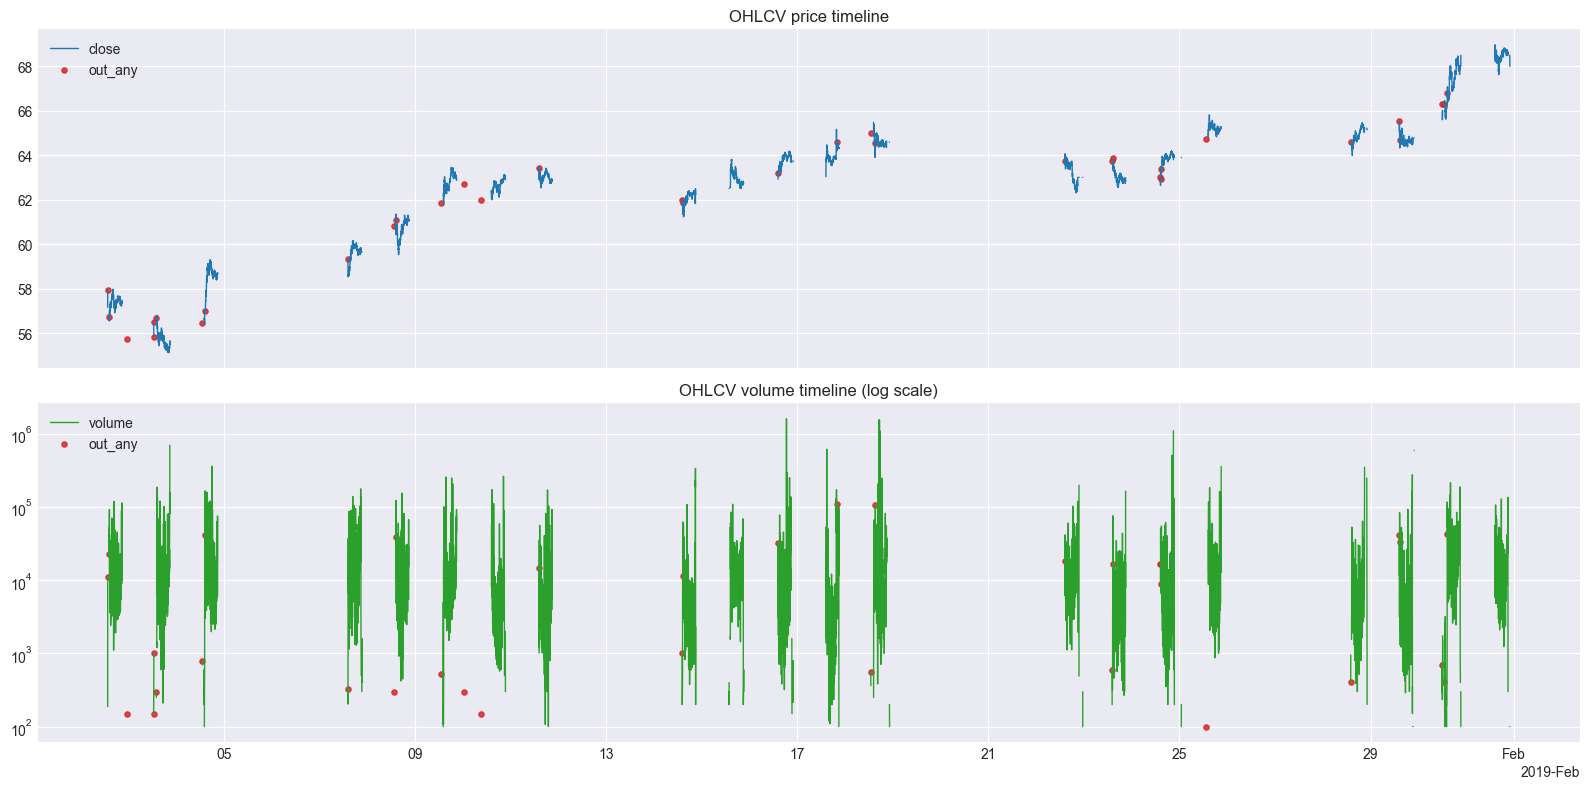

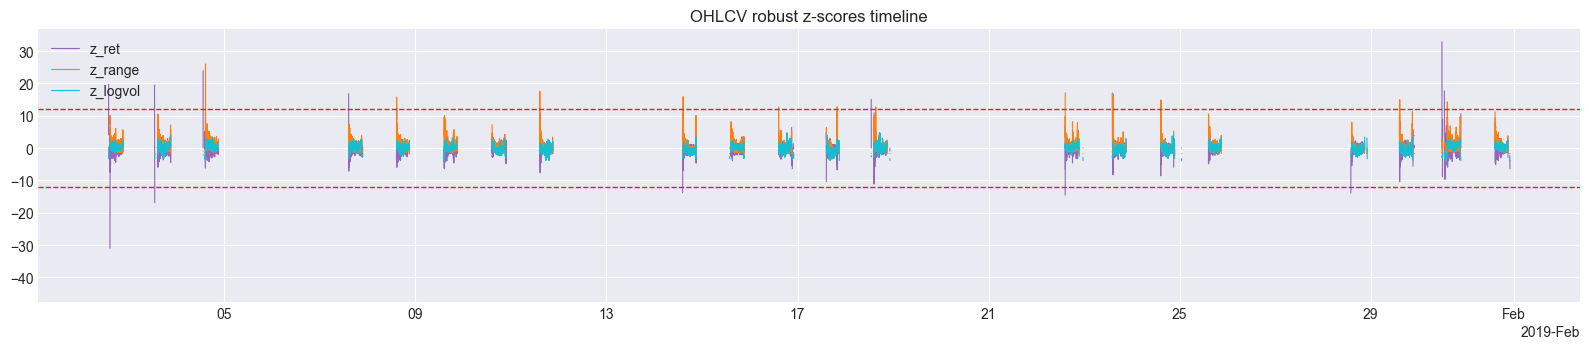

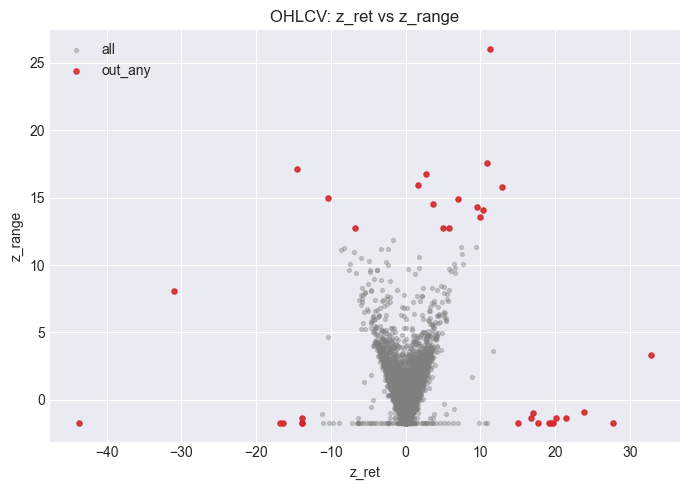

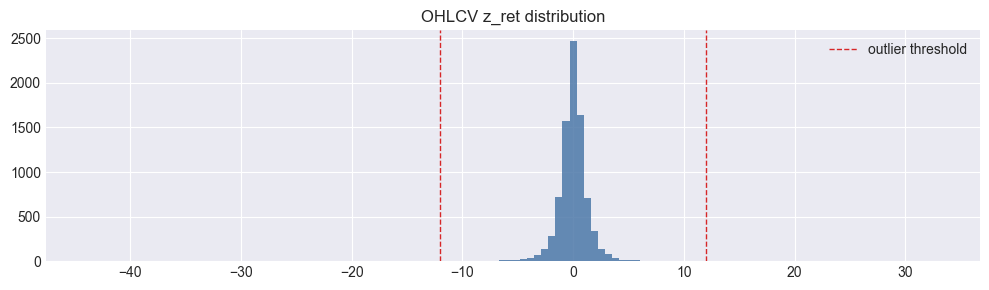

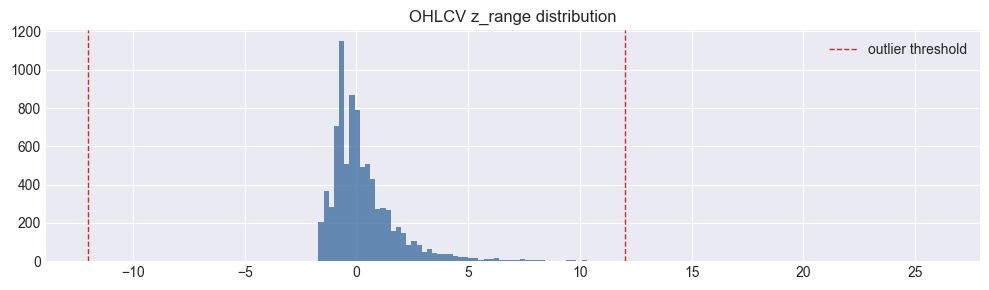

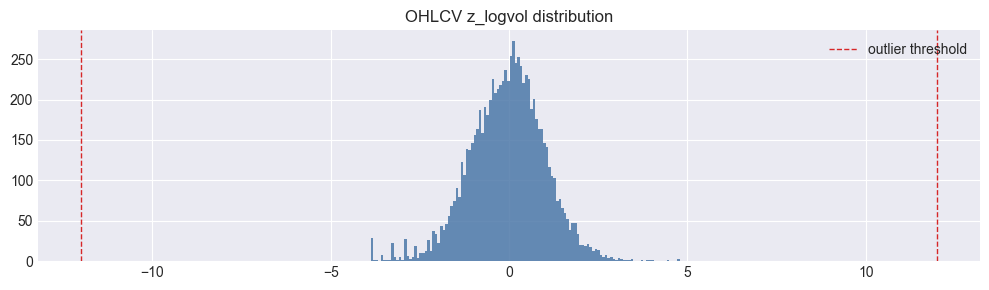

shape: (1, 6)
┌───────────┬───────────┬─────────────┬─────────────┬──────────────┬──────────────┐
│ z_ret_p01 ┆ z_ret_p99 ┆ z_range_p01 ┆ z_range_p99 ┆ z_logvol_p01 ┆ z_logvol_p99 │
│ ---       ┆ ---       ┆ ---         ┆ ---         ┆ ---          ┆ ---          │
│ f64       ┆ f64       ┆ f64         ┆ f64         ┆ f64          ┆ f64          │
╞═══════════╪═══════════╪═════════════╪═════════════╪══════════════╪══════════════╡
│ -3.972268 ┆ 3.851232  ┆ -1.700417   ┆ 7.271541    ┆ -2.905207    ┆ 2.414296     │
└───────────┴───────────┴─────────────┴─────────────┴──────────────┴──────────────┘


minute_ny,open,high,low,close,volume,log_ret,range_bps,log_vol,z_ret,z_range,z_logvol,bad_bounds,out_ret,out_range,out_logvol
"datetime[ns, America/New_York]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool
2019-01-02 18:17:00 EST,55.75,55.75,55.75,55.75,150.0,-0.030038,0.0,5.01728,-43.771901,-1.700417,-3.52223,false,true,false,false
2019-01-30 06:49:00 EST,66.14,66.29,66.14,66.29,700.0,0.022579,22.627847,6.552508,32.90317,3.3335,-2.149036,false,true,false,false
2019-01-02 09:30:00 EST,56.78,56.97,56.72,56.72,22833.0,-0.021281,44.076164,10.036006,-31.011627,8.105011,0.9668,false,true,false,false
2019-01-08 08:46:00 EST,60.8,60.8,60.8,60.8,300.0,0.019096,0.0,5.70711,27.826879,-1.700417,-2.905207,false,true,false,false
2019-01-04 08:18:00 EST,56.43,56.45,56.43,56.45,800.0,0.016432,3.542958,6.685861,23.945141,-0.912231,-2.029757,false,true,false,false
2019-01-03 08:58:00 EST,56.69,56.69,56.68,56.68,300.0,0.014752,1.764291,5.70711,21.497003,-1.307923,-2.905207,false,true,false,false
2019-01-09 08:00:00 EST,61.84,61.85,61.84,61.85,522.0,0.013838,1.616815,6.259581,20.165591,-1.340731,-2.411046,false,true,false,false
2019-01-02 08:50:00 EST,57.94,57.94,57.94,57.94,11114.0,0.013554,0.0,9.316051,19.750868,-1.700417,0.322832,false,true,false,false
2019-01-03 07:53:00 EST,56.5,56.5,56.5,56.5,150.0,0.013363,0.0,5.01728,19.473393,-1.700417,-3.52223,false,true,false,false


In [6]:
# Diagnostics with regime-aware visuals
try:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
except Exception as e:
    plt = None
    print('matplotlib not available:', e)

sample_ohlcv = (
    ohlcv_1m
    .select(["minute_ny", "close", "volume", "z_ret", "z_range", "z_logvol", "out_any"])
    .drop_nulls()
    .limit(200000)
    .collect()
)

if plt is not None and sample_ohlcv.height > 0:
    x = sample_ohlcv["minute_ny"].to_numpy()
    close_vals = sample_ohlcv["close"].to_numpy()
    vol_vals = sample_ohlcv["volume"].to_numpy()
    zret_vals = sample_ohlcv["z_ret"].to_numpy()
    zrange_vals = sample_ohlcv["z_range"].to_numpy()
    zvol_vals = sample_ohlcv["z_logvol"].to_numpy()
    mask = sample_ohlcv["out_any"].to_numpy()

    # Break lines across large gaps to avoid stitched-looking paths.
    x_close, y_close = insert_line_breaks_on_gaps(x, close_vals, max_gap_minutes=10)
    x_vol, y_vol = insert_line_breaks_on_gaps(x, vol_vals, max_gap_minutes=10)
    x_zr, y_zr = insert_line_breaks_on_gaps(x, zret_vals, max_gap_minutes=10)
    x_zra, y_zra = insert_line_breaks_on_gaps(x, zrange_vals, max_gap_minutes=10)
    x_zv, y_zv = insert_line_breaks_on_gaps(x, zvol_vals, max_gap_minutes=10)

    plt.style.use('seaborn-v0_8-darkgrid')

    fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axs[0].plot(x_close, y_close, linewidth=1.0, color="#1f77b4", label="close")
    axs[0].scatter(x[mask], close_vals[mask], s=14, color="#d62728", alpha=0.85, label="out_any")
    axs[0].set_title("OHLCV price timeline")
    axs[0].legend(loc="upper left")

    axs[1].plot(x_vol, y_vol, linewidth=1.0, color="#2ca02c", label="volume")
    axs[1].scatter(x[mask], vol_vals[mask], s=14, color="#d62728", alpha=0.85, label="out_any")
    axs[1].set_yscale('log')
    axs[1].set_title("OHLCV volume timeline (log scale)")
    axs[1].legend(loc="upper left")

    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    axs[1].xaxis.set_major_locator(locator)
    axs[1].xaxis.set_major_formatter(formatter)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(16, 3.6))
    plt.plot(x_zr, y_zr, linewidth=0.8, color="#9467bd", label="z_ret")
    plt.plot(x_zra, y_zra, linewidth=0.8, color="#ff7f0e", label="z_range")
    plt.plot(x_zv, y_zv, linewidth=0.8, color="#17becf", label="z_logvol")
    plt.axhline(THRESH["ret_z_outlier"], color="#d62728", linestyle="--", linewidth=1.0)
    plt.axhline(-THRESH["ret_z_outlier"], color="#d62728", linestyle="--", linewidth=1.0)
    plt.title("OHLCV robust z-scores timeline")
    ax = plt.gca()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.scatter(zret_vals, zrange_vals, s=8, alpha=0.35, color="#7f7f7f", label="all")
    plt.scatter(zret_vals[mask], zrange_vals[mask], s=14, alpha=0.85, color="#d62728", label="out_any")
    plt.title("OHLCV: z_ret vs z_range")
    plt.xlabel("z_ret")
    plt.ylabel("z_range")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    z_thresholds = {
        "z_ret": THRESH["ret_z_outlier"],
        "z_range": THRESH["range_z_outlier"],
        "z_logvol": THRESH["logvol_z_outlier"],
    }
    for col in ["z_ret", "z_range", "z_logvol"]:
        vals = sample_ohlcv[col].to_numpy()
        thr = z_thresholds[col]
        plt.figure(figsize=(10, 3))
        plt.hist(vals, bins=120, color="#4c78a8", alpha=0.85)
        plt.axvline(thr, color="#d62728", linestyle="--", linewidth=1.0, label="outlier threshold")
        plt.axvline(-thr, color="#d62728", linestyle="--", linewidth=1.0)
        plt.title(f"OHLCV {col} distribution")
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

print(sample_ohlcv.select([
    pl.col("z_ret").quantile(0.01).alias("z_ret_p01"),
    pl.col("z_ret").quantile(0.99).alias("z_ret_p99"),
    pl.col("z_range").quantile(0.01).alias("z_range_p01"),
    pl.col("z_range").quantile(0.99).alias("z_range_p99"),
    pl.col("z_logvol").quantile(0.01).alias("z_logvol_p01"),
    pl.col("z_logvol").quantile(0.99).alias("z_logvol_p99"),
]))

top_ohlcv = ohlcv_outliers.head(20).collect()
top_ohlcv



**Step 4: Quotes Outliers (spread y crossed market)**

En small caps, minutos con muy pocos quotes producen spreads inestables. Para evitar falsos positivos:
- Se define `is_liquid_minute = quote_count >= quote_count_liquid_min`.
- La decision de spread/crossed se evalua sobre minutos liquidos.

**Umbrales clave**
- `quote_count_liquid_min = 20`.
- `spread_z_outlier = 12.0`.
- `spread_outlier_ratio_warn/fail = 8% / 20%`.
- `crossed_ratio_warn/fail = 0.5% / 2%`.

Esto preserva sensibilidad a microestructura rota, sin penalizar periodos muertos.



In [7]:
quotes = pl.scan_parquet(quotes_paths)
q_schema = quotes.collect_schema()
qcols = q_schema.names()

bid_col = "bid" if "bid" in qcols else ("bid_price" if "bid_price" in qcols else None)
ask_col = "ask" if "ask" in qcols else ("ask_price" if "ask_price" in qcols else None)
if bid_col is None or ask_col is None:
    raise ValueError(f"No bid/ask columns found. Columns: {qcols}")

q_ts_col = pick_timestamp_col(qcols)
q_ts_dtype = q_schema[q_ts_col]

quotes_c = (
    quotes
    .with_columns([
        pl.col(bid_col).cast(pl.Float64).alias("bid"),
        pl.col(ask_col).cast(pl.Float64).alias("ask"),
        ensure_datetime_ns(pl.col(q_ts_col), q_ts_dtype).alias("ts_raw"),
    ])
    .with_columns([
        to_ny(pl.col("ts_raw")).alias("ts_ny"),
        minute_bucket_ny(to_ny(pl.col("ts_raw"))).alias("minute_ny"),
    ])
    .select([
        "ts_ny",
        "minute_ny",
        "bid",
        "ask",
        ((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid"),
        (pl.col("ask") - pl.col("bid")).alias("spread_abs"),
        (1e4 * (pl.col("ask") - pl.col("bid")) / (((pl.col("bid") + pl.col("ask")) / 2.0) + EPS)).alias("spread_bps"),
        (pl.col("bid") > pl.col("ask")).alias("crossed"),
    ])
)

quotes_1m = (
    quotes_c
    .group_by("minute_ny")
    .agg([
        pl.median("spread_bps").alias("spread_bps_med"),
        pl.mean("crossed").alias("crossed_ratio"),
        pl.len().alias("quote_count"),
    ])
    .sort("minute_ny")
)

q_stats_df = quotes_1m.select(["spread_bps_med"]).collect()
med_spread, mad_spread = robust_stats(q_stats_df["spread_bps_med"])

quotes_1m = quotes_1m.with_columns([
    robust_z(pl.col("spread_bps_med"), med_spread, mad_spread).alias("z_spread"),
    (pl.col("spread_bps_med") < 0).alias("spread_negative"),
    (pl.col("quote_count") >= THRESH["quote_count_liquid_min"]).alias("is_liquid_minute"),
])

quotes_1m = quotes_1m.with_columns([
    ((pl.col("z_spread").abs() >= THRESH["spread_z_outlier"]) & pl.col("is_liquid_minute")).alias("out_spread"),
    ((pl.col("crossed_ratio") >= THRESH["crossed_ratio_fail"]) & pl.col("is_liquid_minute")).alias("crossed_high"),
    (((pl.col("crossed_ratio") >= THRESH["crossed_ratio_warn"]) & pl.col("is_liquid_minute"))).alias("crossed_warn"),
    (pl.col("spread_negative")).alias("bad_spread"),
])

quotes_1m = quotes_1m.with_columns(
    (pl.col("out_spread") | pl.col("crossed_high") | pl.col("bad_spread")).alias("out_any")
)

quotes_metrics = quotes_1m.select([
    pl.len().alias("n_minutes"),
    pl.col("is_liquid_minute").sum().alias("n_liquid_minutes"),
    pl.col("out_spread").sum().alias("n_out_spread"),
    pl.col("crossed_warn").sum().alias("n_crossed_warn"),
    pl.col("crossed_high").sum().alias("n_crossed_fail"),
    pl.col("bad_spread").sum().alias("n_bad_spread"),
    pl.col("out_any").sum().alias("n_out_any"),
]).collect().row(0)

q_n_minutes = int(quotes_metrics[0])
q_n_liquid_minutes = int(quotes_metrics[1])
q_n_out_any = int(quotes_metrics[6])
q_ratio_out_any = q_n_out_any / max(q_n_liquid_minutes, 1)
q_crossed_fail_ratio = float(quotes_metrics[4]) / max(q_n_liquid_minutes, 1)

status_spread = status_from_ratio(q_ratio_out_any, THRESH["spread_outlier_ratio_warn"], THRESH["spread_outlier_ratio_fail"])
status_crossed = status_from_ratio(q_crossed_fail_ratio, THRESH["crossed_ratio_warn"], THRESH["crossed_ratio_fail"])

status_quotes = combine_status(status_spread, status_crossed)

quotes_outliers = (
    quotes_1m
    .filter(pl.col("out_any"))
    .select([
        "minute_ny",
        "spread_bps_med",
        "crossed_ratio",
        "quote_count",
        "is_liquid_minute",
        "z_spread",
        "out_spread",
        "bad_spread",
        "crossed_high",
    ])
    .sort(pl.col("z_spread").abs(), descending=True)
)

quotes_outliers.collect().write_parquet(OUT_DIR / "quotes_outliers.parquet")



**Step 4 Result: Quotes Outliers**

Se reporta:
- `n_minutes`, `n_liquid_minutes`.
- `n_out_spread`, `n_crossed_warn`, `n_crossed_fail`, `n_out_any`.
- Ratios sobre minutos liquidos: `ratio_out_any_on_liquid`, `ratio_crossed_fail_on_liquid`.

**Interpretacion correcta**
- El denominador relevante es liquidez efectiva, no todos los minutos del mes.
- Si `n_liquid_minutes` es bajo, la confianza de la decision debe revisarse con evidencia visual adicional.



In [8]:
print('Quotes n_minutes:', q_n_minutes)
print('Quotes n_liquid_minutes:', q_n_liquid_minutes, 'min quotes:', THRESH["quote_count_liquid_min"])
print('Quotes n_out_any:', q_n_out_any, 'ratio_on_liquid:', q_ratio_out_any)
print('Quotes crossed FAIL minutes:', int(quotes_metrics[4]), 'ratio_on_liquid:', q_crossed_fail_ratio)
print('Quotes status (spread):', status_spread)
print('Quotes status (crossed):', status_crossed)
print('Quotes status (overall):', status_quotes)



Quotes n_minutes: 6747
Quotes n_liquid_minutes: 6747 min quotes: 20
Quotes n_out_any: 357 ratio_on_liquid: 0.052912405513561585
Quotes crossed FAIL minutes: 2 ratio_on_liquid: 0.00029642804209278195
Quotes status (spread): PASS
Quotes status (crossed): PASS
Quotes status (overall): PASS


**Step 4 Diagnostics: Quotes Visuals**

Incluye tres timelines:
- `spread_bps_med` (con flags).
- `crossed_ratio` con lineas de umbral `warn/fail`.
- `quote_count` con linea de corte de liquidez.

Y histogramas solo en minutos liquidos.

**Objetivo**
- Ver separacion entre regime dormido y regime activo.
- Validar que los `FAIL/WARN` no vengan de micro-liquidez extrema no operable.



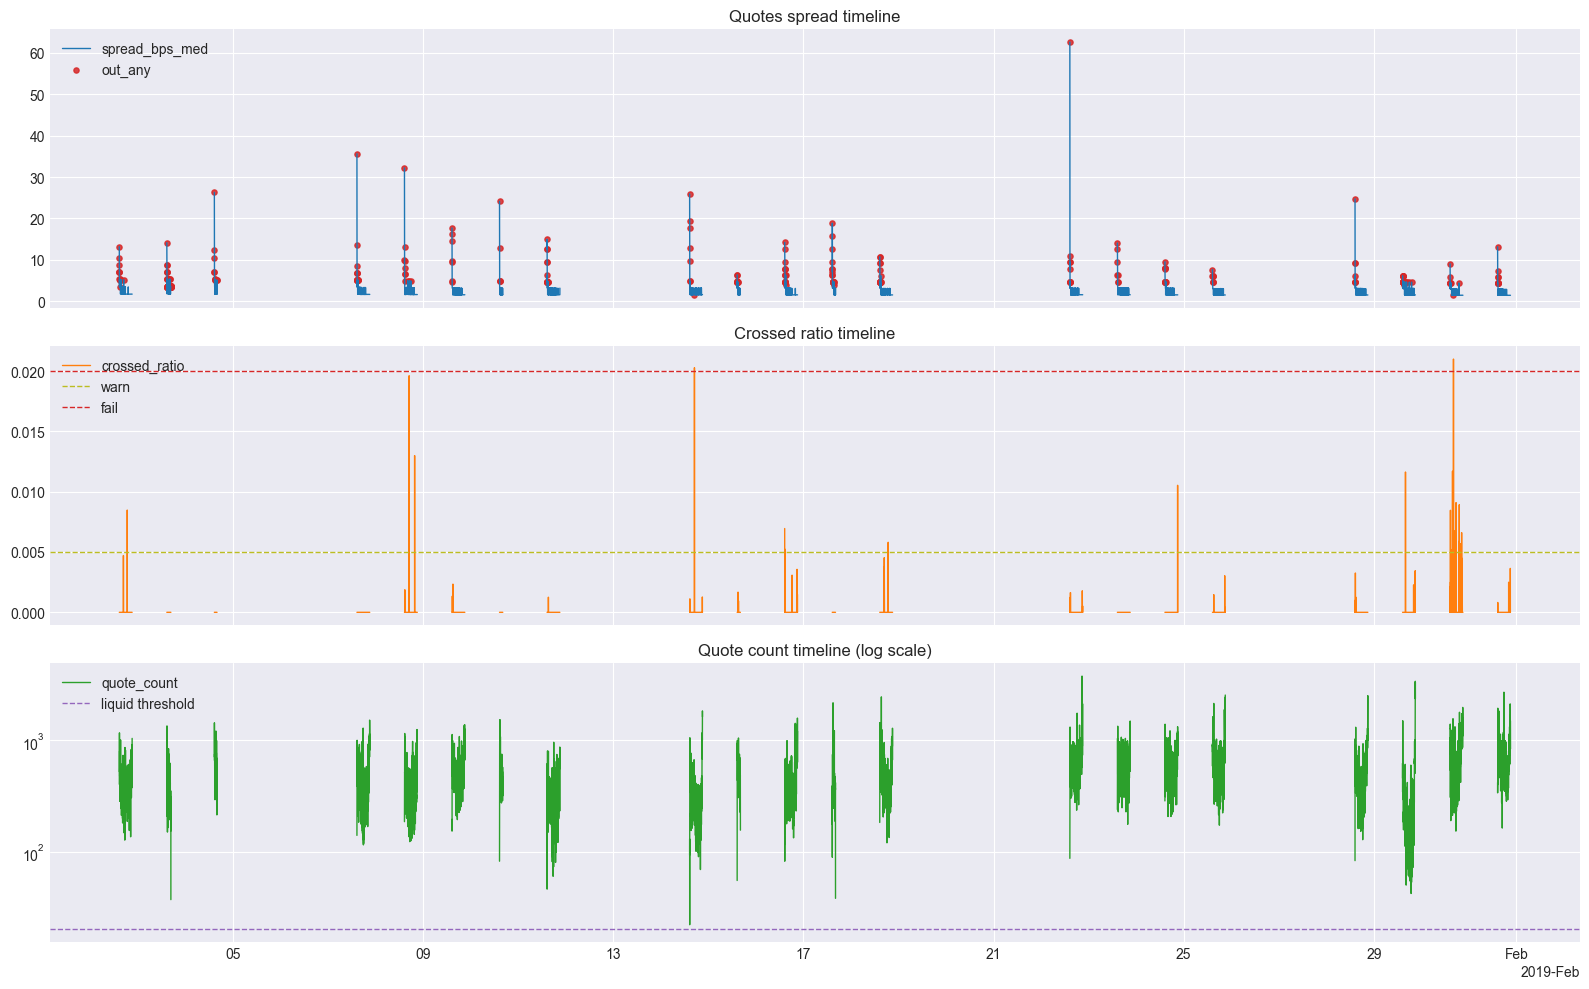

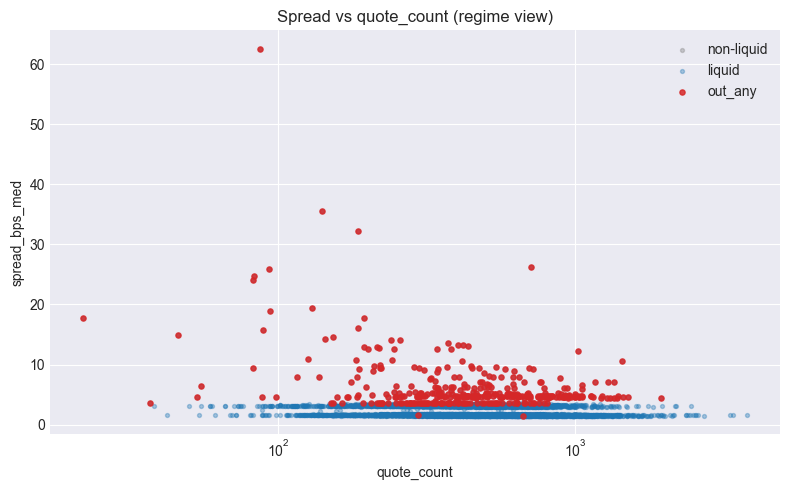

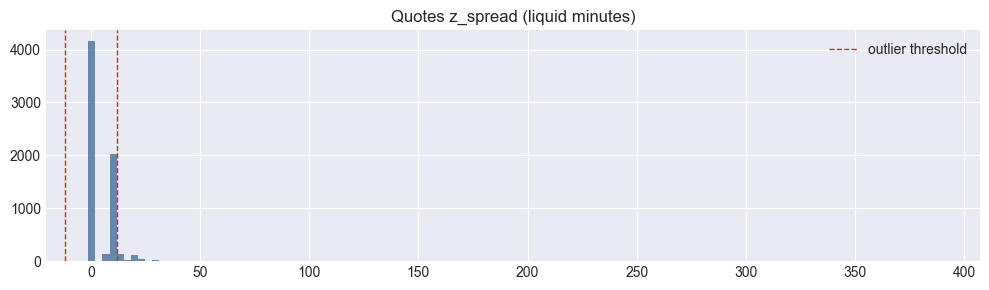

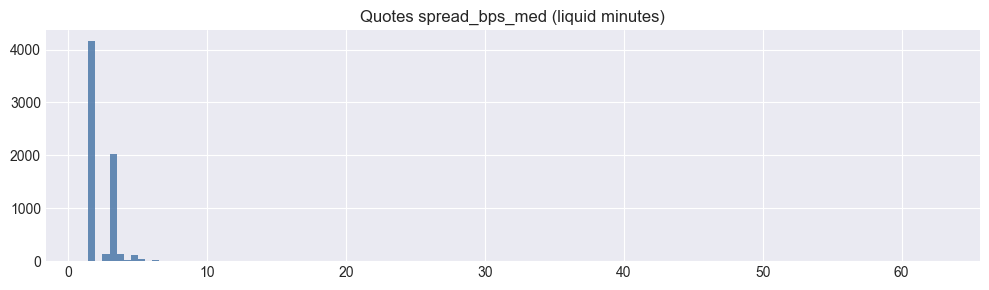

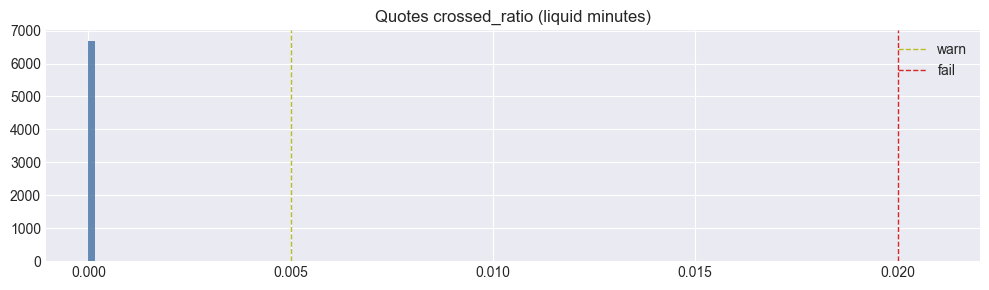

shape: (1, 5)
┌──────────────┬──────────────┬────────────┬────────────┬─────────────┐
│ z_spread_p01 ┆ z_spread_p99 ┆ spread_p01 ┆ spread_p99 ┆ crossed_p99 │
│ ---          ┆ ---          ┆ ---        ┆ ---        ┆ ---         │
│ f64          ┆ f64          ┆ f64        ┆ f64        ┆ f64         │
╞══════════════╪══════════════╪════════════╪════════════╪═════════════╡
│ -1.152392    ┆ 39.423454    ┆ 1.455922   ┆ 7.833921   ┆ 0.000815    │
└──────────────┴──────────────┴────────────┴────────────┴─────────────┘


minute_ny,spread_bps_med,crossed_ratio,quote_count,is_liquid_minute,z_spread,out_spread,bad_spread,crossed_high
"datetime[ms, America/New_York]",f64,f64,u32,bool,f64,bool,bool,bool
2019-01-22 09:30:00 EST,62.588014,0.0,87,true,387.76056,true,false,false
2019-01-07 09:30:00 EST,35.620388,0.0,140,true,216.196679,true,false,false
2019-01-08 09:30:00 EST,32.220778,0.0,186,true,194.568879,true,false,false
2019-01-04 09:30:00 EST,26.318099,0.0,712,true,157.016947,true,false,false
2019-01-14 09:30:00 EST,25.923526,0.0,93,true,154.506732,true,false,false
2019-01-28 09:30:00 EST,24.744819,0.0,83,true,147.007983,true,false,false
2019-01-10 09:30:00 EST,24.137099,0.0,82,true,143.14176,true,false,false
2019-01-14 09:31:00 EST,19.379845,0.0,130,true,112.876844,true,false,false
2019-01-17 09:34:00 EST,18.867925,0.0,94,true,109.620085,true,false,false


In [9]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
except Exception as e:
    plt = None
    print('matplotlib not available:', e)

sample_quotes = (
    quotes_1m
    .select(["minute_ny", "z_spread", "spread_bps_med", "crossed_ratio", "quote_count", "is_liquid_minute", "out_any"])
    .drop_nulls()
    .limit(200000)
    .collect()
)

if plt is not None and sample_quotes.height > 0:
    x = sample_quotes["minute_ny"].to_numpy()
    spread_vals = sample_quotes["spread_bps_med"].to_numpy()
    crossed_vals = sample_quotes["crossed_ratio"].to_numpy()
    qcount_vals = sample_quotes["quote_count"].to_numpy()
    liquid_mask = sample_quotes["is_liquid_minute"].to_numpy()
    out_mask = sample_quotes["out_any"].to_numpy()

    x_sp, y_sp = insert_line_breaks_on_gaps(x, spread_vals, max_gap_minutes=10)
    x_cr, y_cr = insert_line_breaks_on_gaps(x, crossed_vals, max_gap_minutes=10)
    x_qc, y_qc = insert_line_breaks_on_gaps(x, qcount_vals, max_gap_minutes=10)

    plt.style.use('seaborn-v0_8-darkgrid')

    fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axs[0].plot(x_sp, y_sp, linewidth=1.0, color="#1f77b4", label="spread_bps_med")
    axs[0].scatter(x[out_mask], spread_vals[out_mask], s=14, color="#d62728", alpha=0.85, label="out_any")
    axs[0].set_title("Quotes spread timeline")
    axs[0].legend(loc="upper left")

    axs[1].plot(x_cr, y_cr, linewidth=1.0, color="#ff7f0e", label="crossed_ratio")
    axs[1].axhline(THRESH["crossed_ratio_warn"], color="#bcbd22", linestyle="--", linewidth=1.0, label="warn")
    axs[1].axhline(THRESH["crossed_ratio_fail"], color="#d62728", linestyle="--", linewidth=1.0, label="fail")
    axs[1].set_title("Crossed ratio timeline")
    axs[1].legend(loc="upper left")

    axs[2].plot(x_qc, y_qc, linewidth=1.0, color="#2ca02c", label="quote_count")
    axs[2].axhline(THRESH["quote_count_liquid_min"], color="#9467bd", linestyle="--", linewidth=1.0, label="liquid threshold")
    axs[2].set_yscale('log')
    axs[2].set_title("Quote count timeline (log scale)")
    axs[2].legend(loc="upper left")

    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    axs[2].xaxis.set_major_locator(locator)
    axs[2].xaxis.set_major_formatter(formatter)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(qcount_vals[~liquid_mask], spread_vals[~liquid_mask], s=8, alpha=0.35, color="#7f7f7f", label="non-liquid")
    plt.scatter(qcount_vals[liquid_mask], spread_vals[liquid_mask], s=8, alpha=0.35, color="#1f77b4", label="liquid")
    plt.scatter(qcount_vals[out_mask], spread_vals[out_mask], s=14, alpha=0.85, color="#d62728", label="out_any")
    plt.xscale('log')
    plt.title("Spread vs quote_count (regime view)")
    plt.xlabel("quote_count")
    plt.ylabel("spread_bps_med")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    for col in ["z_spread", "spread_bps_med", "crossed_ratio"]:
        vals = sample_quotes.filter(pl.col("is_liquid_minute"))[col].to_numpy()
        if len(vals) == 0:
            continue
        plt.figure(figsize=(10, 3))
        plt.hist(vals, bins=120, color="#4c78a8", alpha=0.85)
        if col == "z_spread":
            plt.axvline(THRESH["spread_z_outlier"], color="#d62728", linestyle="--", linewidth=1.0, label="outlier threshold")
            plt.axvline(-THRESH["spread_z_outlier"], color="#d62728", linestyle="--", linewidth=1.0)
            plt.legend(loc="upper right")
        if col == "crossed_ratio":
            plt.axvline(THRESH["crossed_ratio_warn"], color="#bcbd22", linestyle="--", linewidth=1.0, label="warn")
            plt.axvline(THRESH["crossed_ratio_fail"], color="#d62728", linestyle="--", linewidth=1.0, label="fail")
            plt.legend(loc="upper right")
        plt.title(f"Quotes {col} (liquid minutes)")
        plt.tight_layout()
        plt.show()

print(sample_quotes.select([
    pl.col("z_spread").quantile(0.01).alias("z_spread_p01"),
    pl.col("z_spread").quantile(0.99).alias("z_spread_p99"),
    pl.col("spread_bps_med").quantile(0.01).alias("spread_p01"),
    pl.col("spread_bps_med").quantile(0.99).alias("spread_p99"),
    pl.col("crossed_ratio").quantile(0.99).alias("crossed_p99"),
]))

top_quotes = quotes_outliers.head(20).collect()
top_quotes



**Step 5: Trades Outliers (opcional)**

Si el manifest incluye trades:
- Se agrega por minuto y se calculan `z_ret` y `z_logvol`.
- Se evalua `out_any` y ratio agregado con los umbrales del universo small caps.

Si no hay trades en el slice, este bloque se omite y queda documentado en salida.



In [10]:
trades_present = len(trades_paths) > 0
status_trades = "PASS"
trade_metrics = None

t_ratio_out_any = 0.0

if trades_present:
    trades = pl.scan_parquet(trades_paths)
    t_schema = trades.collect_schema()
    tcols = t_schema.names()

    price_col = "price" if "price" in tcols else ("trade_price" if "trade_price" in tcols else None)
    size_col = "size" if "size" in tcols else ("trade_size" if "trade_size" in tcols else None)
    if price_col is None or size_col is None:
        raise ValueError(f"No price/size columns found in trades. Columns: {tcols}")

    t_ts_col = pick_timestamp_col(tcols)
    t_ts_dtype = t_schema[t_ts_col]

    trades_c = (
        trades
        .with_columns([
            pl.col(price_col).cast(pl.Float64).alias("price"),
            pl.col(size_col).cast(pl.Float64).alias("size"),
            ensure_datetime_ns(pl.col(t_ts_col), t_ts_dtype).alias("ts_raw"),
        ])
        .with_columns([
            to_ny(pl.col("ts_raw")).alias("ts_ny"),
            minute_bucket_ny(to_ny(pl.col("ts_raw"))).alias("minute_ny"),
        ])
        .select([
            "minute_ny",
            "price",
            "size",
        ])
    )

    trades_1m = (
        trades_c
        .group_by("minute_ny")
        .agg([
            pl.first("price").alias("open"),
            pl.max("price").alias("high"),
            pl.min("price").alias("low"),
            pl.last("price").alias("close"),
            pl.sum("size").alias("volume"),
            pl.len().alias("trade_rows_in_minute"),
        ])
        .sort("minute_ny")
    )

    trades_1m = trades_1m.with_columns([
        pl.when(pl.col("close") > 0).then(pl.col("close").log()).otherwise(None).alias("log_close"),
        pl.col("volume").log1p().alias("log_vol"),
    ])

    trades_1m = trades_1m.with_columns([
        pl.col("log_close").diff().alias("log_ret"),
    ])

    t_stats_df = trades_1m.select(["log_ret", "log_vol"]).collect()
    t_med_ret, t_mad_ret = robust_stats(t_stats_df["log_ret"])
    t_med_logvol, t_mad_logvol = robust_stats(t_stats_df["log_vol"])

    trades_1m = trades_1m.with_columns([
        robust_z(pl.col("log_ret"), t_med_ret, t_mad_ret).alias("z_ret"),
        robust_z(pl.col("log_vol"), t_med_logvol, t_mad_logvol).alias("z_logvol"),
    ])

    trades_1m = trades_1m.with_columns([
        (pl.col("z_ret").abs() >= THRESH["trade_ret_z_outlier"]).alias("out_ret"),
        (pl.col("z_logvol").abs() >= THRESH["trade_logsize_z_outlier"]).alias("out_logvol"),
    ])

    trades_1m = trades_1m.with_columns(
        (pl.col("out_ret") | pl.col("out_logvol")).alias("out_any")
    )

    trade_metrics = trades_1m.select([
        pl.len().alias("n_minutes"),
        pl.col("out_ret").sum().alias("n_out_ret"),
        pl.col("out_logvol").sum().alias("n_out_logvol"),
        pl.col("out_any").sum().alias("n_out_any"),
    ]).collect().row(0)

    t_n_minutes = int(trade_metrics[0])
    t_n_out_any = int(trade_metrics[3])
    t_ratio_out_any = t_n_out_any / max(t_n_minutes, 1)
    status_trades = status_from_ratio(t_ratio_out_any, THRESH["outlier_ratio_warn"], THRESH["outlier_ratio_fail"])

    trades_outliers = (
        trades_1m
        .filter(pl.col("out_any"))
        .select([
            "minute_ny",
            "open", "high", "low", "close", "volume",
            "log_ret", "log_vol",
            "z_ret", "z_logvol",
            "out_ret", "out_logvol",
        ])
        .sort(pl.col("z_ret").abs(), descending=True)
    )

    trades_outliers.collect().write_parquet(OUT_DIR / "trades_outliers.parquet")

else:
    print("No trades files in manifest; skipping trades outlier checks.")



No trades files in manifest; skipping trades outlier checks.


**Step 5 Result: Trades Outliers**

Se reporta:
- `n_minutes`, `n_out_ret`, `n_out_logvol`, `n_out_any`, `ratio_out_any`.
- Estado final `PASS/WARN/FAIL` para trades.

En pump-and-dump, colas pesadas en retornos son esperables; la decision debe mirar ratio agregado y no minutos aislados.



In [11]:
print('Trades present:', trades_present)
if trade_metrics is not None:
    print('Trades n_minutes:', int(trade_metrics[0]))
    print('Trades n_out_any:', int(trade_metrics[3]), 'ratio:', t_ratio_out_any)
print('Trades status:', status_trades)


Trades present: False
Trades status: PASS


**Step 5 Diagnostics: Trades Visuals**

Incluye:
- Timeline de precio derivado de trades con flags.
- Timeline de volumen con wake-up spikes.
- Histogramas de `z_ret` y `z_logvol`.

Esto ayuda a validar si el feed de trades confirma (o contradice) los eventos detectados en OHLCV/Quotes.



In [12]:
if trades_present:
    try:
        import matplotlib.pyplot as plt
        import matplotlib.dates as mdates
    except Exception as e:
        plt = None
        print('matplotlib not available:', e)

    sample_trades = (
        trades_1m
        .select(["minute_ny", "close", "volume", "z_ret", "z_logvol", "out_any"])
        .drop_nulls()
        .limit(200000)
        .collect()
    )

    if plt is not None and sample_trades.height > 0:
        x = sample_trades["minute_ny"].to_numpy()
        close_vals = sample_trades["close"].to_numpy()
        vol_vals = sample_trades["volume"].to_numpy()
        zret_vals = sample_trades["z_ret"].to_numpy()
        zvol_vals = sample_trades["z_logvol"].to_numpy()
        mask = sample_trades["out_any"].to_numpy()

        x_close, y_close = insert_line_breaks_on_gaps(x, close_vals, max_gap_minutes=10)
        x_vol, y_vol = insert_line_breaks_on_gaps(x, vol_vals, max_gap_minutes=10)
        x_zr, y_zr = insert_line_breaks_on_gaps(x, zret_vals, max_gap_minutes=10)
        x_zv, y_zv = insert_line_breaks_on_gaps(x, zvol_vals, max_gap_minutes=10)

        plt.style.use('seaborn-v0_8-darkgrid')

        fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
        axs[0].plot(x_close, y_close, linewidth=1.0, color="#1f77b4", label="trade-close")
        axs[0].scatter(x[mask], close_vals[mask], s=14, color="#d62728", alpha=0.85, label="out_any")
        axs[0].set_title("Trades-derived price timeline")
        axs[0].legend(loc="upper left")

        axs[1].plot(x_vol, y_vol, linewidth=1.0, color="#2ca02c", label="trade-volume")
        axs[1].scatter(x[mask], vol_vals[mask], s=14, color="#d62728", alpha=0.85, label="out_any")
        axs[1].set_yscale('log')
        axs[1].set_title("Trades-derived volume timeline (log scale)")
        axs[1].legend(loc="upper left")

        locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
        formatter = mdates.ConciseDateFormatter(locator)
        axs[1].xaxis.set_major_locator(locator)
        axs[1].xaxis.set_major_formatter(formatter)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(16, 3.6))
        plt.plot(x_zr, y_zr, linewidth=0.8, color="#9467bd", label="z_ret")
        plt.plot(x_zv, y_zv, linewidth=0.8, color="#17becf", label="z_logvol")
        plt.axhline(THRESH["trade_ret_z_outlier"], color="#d62728", linestyle="--", linewidth=1.0)
        plt.axhline(-THRESH["trade_ret_z_outlier"], color="#d62728", linestyle="--", linewidth=1.0)
        plt.title("Trades robust z-scores timeline")
        ax = plt.gca()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.scatter(zret_vals, zvol_vals, s=8, alpha=0.35, color="#7f7f7f", label="all")
        plt.scatter(zret_vals[mask], zvol_vals[mask], s=14, alpha=0.85, color="#d62728", label="out_any")
        plt.title("Trades: z_ret vs z_logvol")
        plt.xlabel("z_ret")
        plt.ylabel("z_logvol")
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

        z_thresholds = {
            "z_ret": THRESH["trade_ret_z_outlier"],
            "z_logvol": THRESH["trade_logsize_z_outlier"],
        }
        for col in ["z_ret", "z_logvol"]:
            vals = sample_trades[col].to_numpy()
            thr = z_thresholds[col]
            plt.figure(figsize=(10, 3))
            plt.hist(vals, bins=120, color="#4c78a8", alpha=0.85)
            plt.axvline(thr, color="#d62728", linestyle="--", linewidth=1.0, label="outlier threshold")
            plt.axvline(-thr, color="#d62728", linestyle="--", linewidth=1.0)
            plt.title(f"Trades {col} distribution")
            plt.legend(loc="upper right")
            plt.tight_layout()
            plt.show()

    print(sample_trades.select([
        pl.col("z_ret").quantile(0.01).alias("z_ret_p01"),
        pl.col("z_ret").quantile(0.99).alias("z_ret_p99"),
        pl.col("z_logvol").quantile(0.01).alias("z_logvol_p01"),
        pl.col("z_logvol").quantile(0.99).alias("z_logvol_p99"),
    ]))

    top_trades = trades_outliers.head(20).collect()
    top_trades



**Resumen y Decision Final**

Se consolida `overall = combine_status(status_ohlcv, status_quotes, status_trades)`.

**Regla de combinacion**
- Si algun bloque falla: `OVERALL = FAIL`.
- Si no hay FAIL pero hay WARN: `OVERALL = WARN`.
- Solo `PASS` cuando todos estan en PASS.

El `summary.json` es el contrato de salida para el gate de calidad y debe versionarse por run.



**Limitaciones y Riesgos (small caps / pump-and-dump)**

1. `Halts y resumptions`: un halt puede concentrar retorno/rango en pocos minutos y parecer anomalia estadistica sin ser corrupcion.
2. `Late prints / correcciones`: algunos prints pueden llegar fuera de secuencia y contaminar barras de 1m.
3. `Spoofing / quote stuffing`: spread y crossed pueden deteriorarse por conducta microestructural, no solo por mala calidad de feed.
4. `Cobertura incompleta`: ausencia de trades o baja densidad de quotes reduce la potencia del test en ciertos tramos.
5. `Riesgo de sobrecalibracion`: umbrales ajustados a un slice (ej. AABA 2019-01) pueden no generalizar a otros simbolos/epocas.

**Controles recomendados**
- Calibrar umbrales por bucket de liquidez/market-cap y por periodo historico.
- Separar decisiones en `RTH` vs `extended hours`.
- Revisar manualmente top outliers por evento corporativo/noticia cuando afecte decisiones de estrategia.
- Versionar umbrales y exigir evidencia visual cuando un cambio altere `overall`.

**Regla de uso para research/backtest**
- `PASS`: usar slice para investigacion y simulacion base.
- `WARN`: usar con etiquetas de riesgo y analisis adicional por evento.
- `FAIL`: no usar para inferencias de estrategia sin depuracion/correccion previa.



In [13]:
overall_status = combine_status(status_ohlcv, status_quotes, status_trades)


applicability_status = "APPLICABLE"
root_causes = []
if status_ohlcv in {"WARN", "FAIL"}:
    root_causes.append("sample_issue")
if status_quotes in {"WARN", "FAIL"}:
    root_causes.append("microstructure_friction")
if status_trades in {"WARN", "FAIL"}:
    root_causes.append("schema_gap")
root_cause = ",".join(sorted(set(root_causes))) if root_causes else "none"

gate_breakdown = [
    {"gate": "ohlcv_quality", "status": status_ohlcv},
    {"gate": "quotes_quality", "status": status_quotes},
    {"gate": "trades_quality", "status": status_trades},
]

ticker_val = str(globals().get("SYMBOL", globals().get("TICKER", "AABA")))
decision_table = [{
    "ticker": ticker_val,
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "ohlcv_status": status_ohlcv,
    "quotes_status": status_quotes,
    "trades_status": status_trades,
    "decision": overall_status,
}]

summary = {
    "run_id": RUN_ID,
    "manifest": str(MANIFEST_PATH),
    "cache_dir": str(DATA_CACHE_DIR),
    "timezone_canonical": NY_TZ,
    "thresholds": THRESH,
    "ohlcv": {
        "n_minutes": int(ohlcv_metrics[0]),
        "n_bad_bounds": int(ohlcv_metrics[1]),
        "n_out_ret": int(ohlcv_metrics[2]),
        "n_out_range": int(ohlcv_metrics[3]),
        "n_out_logvol": int(ohlcv_metrics[4]),
        "n_out_any": int(ohlcv_metrics[5]),
        "ratio_bad_bounds": float(ratio_bad_bounds),
        "ratio_out_any": float(ratio_out_any),
        "status": status_ohlcv,
    },
    "quotes": {
        "n_minutes": int(quotes_metrics[0]),
        "n_liquid_minutes": int(quotes_metrics[1]),
        "n_out_spread": int(quotes_metrics[2]),
        "n_crossed_warn": int(quotes_metrics[3]),
        "n_crossed_fail": int(quotes_metrics[4]),
        "n_bad_spread": int(quotes_metrics[5]),
        "n_out_any": int(quotes_metrics[6]),
        "ratio_out_any_on_liquid": float(q_ratio_out_any),
        "ratio_crossed_fail_on_liquid": float(q_crossed_fail_ratio),
        "status": status_quotes,
    },
    "trades": {
        "present": bool(trades_present),
        "metrics": trade_metrics if trade_metrics is None else {
            "n_minutes": int(trade_metrics[0]),
            "n_out_ret": int(trade_metrics[1]),
            "n_out_logvol": int(trade_metrics[2]),
            "n_out_any": int(trade_metrics[3]),
            "ratio_out_any": float(t_ratio_out_any),
        },
        "status": status_trades,
    },
    "overall": overall_status,
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "gate_breakdown": gate_breakdown,
    "decision_table": decision_table,
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Summary saved to:", OUT_DIR / "summary.json")
print("OVERALL:", overall_status)



Summary saved to: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_outliers_and_anomalies\20260211_191705_35243b71\summary.json
OVERALL: PASS
